1. Area of interest

- A map illustrating the location of the watershed of interest.
- Icons illustrating the location of the USGS station.
- Icons illustrating the location of the SNOTEL station(s).
- A description of the watershed (e.g., area, elevation range, vegetation, etc).

In [1]:
from __future__ import annotations

from pathlib import Path
import dataretrieval.nwis as nwis
from datetime import datetime
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pynhd as nhd
from pynhd import NLDI, NHDPlusHR, WaterData
import py3dep
import pygeohydro as gh

from pathlib import Path
import networkx as nx
import xarray as xr
import xrspatial
import os

from supporting_scripts import mapping, dataprocessing
import datetime

In [2]:
nldi = NLDI()
station_id = "09010500" # NWIS id for Colorado River below Baker Gulch
WY = 2019



In [3]:
basinname = 'ColoradoRiverBasin'
#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(station_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file(f"files/{basinname}.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{station_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{station_id}", "upstreamMain", "flowlines", distance=9999
)

In [4]:
mapping.basin_mapping(basin, site_feature) #create a map to show where the catchment is

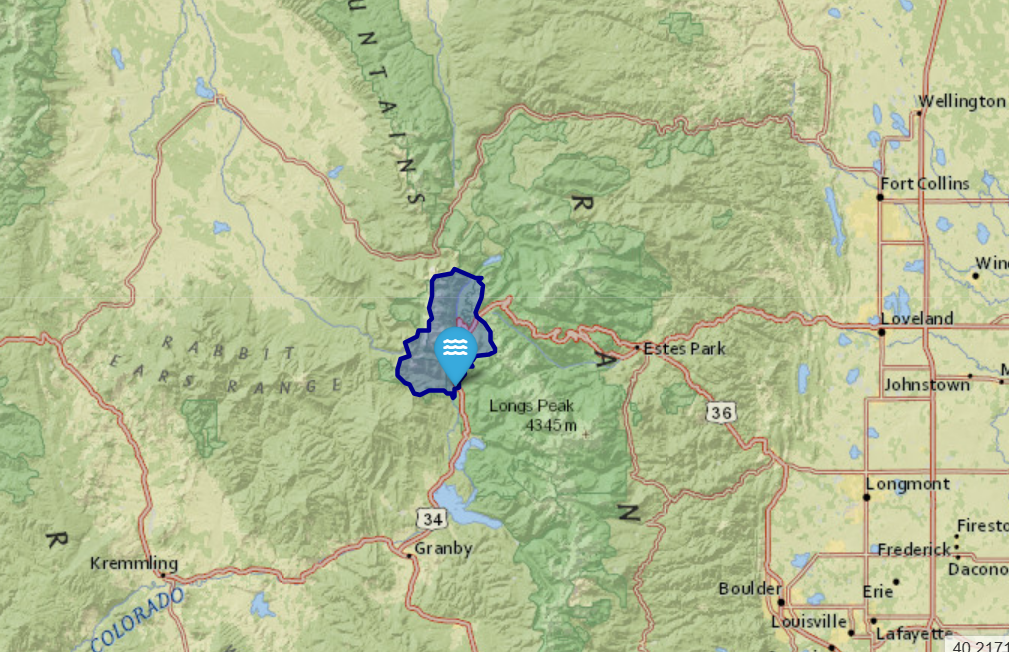

In [5]:
# Identify Snotel Sites within Basin
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry.iloc[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

/uufs/chpc.utah.edu/common/home/u1405836/.conda/envs/hyriver/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,565_CO_SNTL,Lake Irene,SNOTEL,3261.360107,40.414322,-105.819801,Colorado,140100010302,13TDE,Southern Rocky Mountains,1978-10-01,2026-03-29,True,POINT (-105.8198 40.41432)
1,688_CO_SNTL,Phantom Valley,SNOTEL,2752.343994,40.399368,-105.847572,Colorado,140100010302,13TDE,Southern Rocky Mountains,1979-10-01,2026-03-29,True,POINT (-105.84757 40.39937)


In [6]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

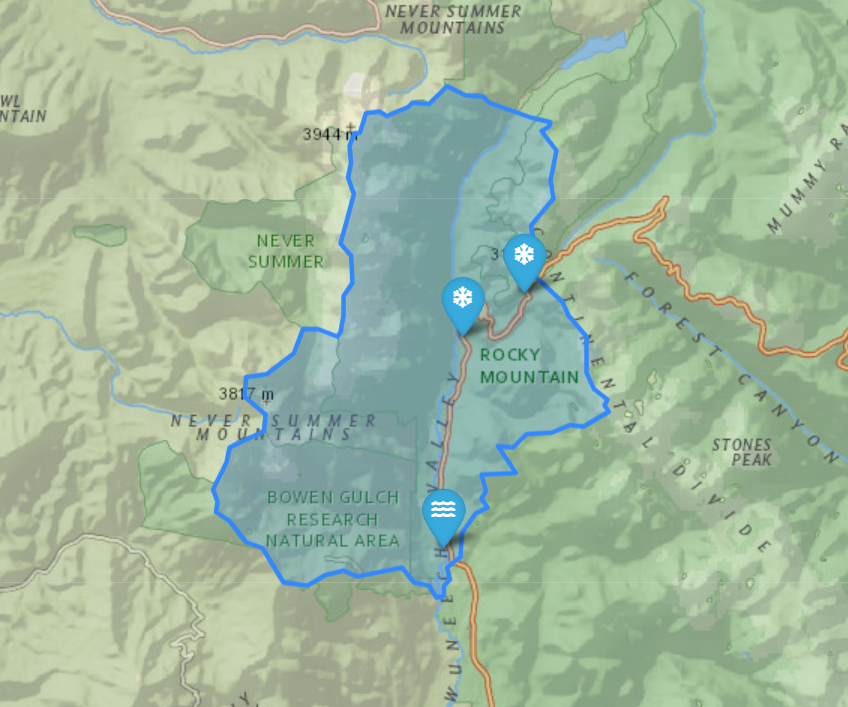

Snotel Sites: 

PHANTOM VALLEY, CO (688) SNOW WATER EQUIVALENT

LAKE IRENE, CO (565) SNOW WATER EQUIVALENT


In [7]:
#Pull SNOTEL/SWE data

# '''
# Data pulled from: Gagliano, E. (2024).
# snotel_ccss_stations (Version v1.0) [Computer software]. https://github.com/egagli/snotel_ccss_stations
# '''

#read csv into dataframe
snotel_688 = pd.read_csv('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/refs/heads/main/data/688_CO_SNTL.csv')
print("CSV 1 loaded successfully")
print(snotel_688.head()) #Display first five rows
print(snotel_688.tail())


CSV 1 loaded successfully
     datetime  TAVG  TMIN  TMAX  SNWD  WTEQ  PRCPSA
0  1980-10-01   NaN   NaN   NaN   NaN   0.0     0.0
1  1980-10-02   NaN   NaN   NaN   NaN   0.0     0.0
2  1980-10-03   NaN   NaN   NaN   NaN   0.0     0.0
3  1980-10-04   NaN   NaN   NaN   NaN   0.0     0.0
4  1980-10-05   NaN   NaN   NaN   NaN   0.0     0.0
         datetime  TAVG  TMIN  TMAX    SNWD    WTEQ  PRCPSA
16611  2026-03-25   9.4   0.2  18.9     NaN     NaN     NaN
16612  2026-03-26   7.6  -1.6  17.4  0.1778  0.0635     0.0
16613  2026-03-27   3.3  -4.3  12.8  0.1270  0.0483     0.0
16614  2026-03-28   5.7  -3.6  16.0  0.0762  0.0305     0.0
16615  2026-03-29   NaN   NaN   NaN  0.0254  0.0178     NaN


In [8]:
#Read Lake Irene SNOTEL Data
#read csv into dataframe
snotel_565 = pd.read_csv('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/refs/heads/main/data/565_CO_SNTL.csv')
print("CSV 1 loaded successfully")
print(snotel_565.head()) #Display first five rows
print(snotel_565.tail())

CSV 1 loaded successfully
     datetime  TAVG  TMIN  TMAX  SNWD  WTEQ  PRCPSA
0  1978-10-01   NaN   NaN   NaN   NaN   NaN     0.0
1  1978-10-02   NaN   NaN   NaN   NaN   NaN     0.0
2  1978-10-03   NaN   NaN   NaN   NaN   NaN     0.0
3  1978-10-04   NaN   NaN   NaN   NaN   NaN     0.0
4  1978-10-05   NaN   NaN   NaN   NaN   NaN     0.0
         datetime  TAVG  TMIN  TMAX    SNWD    WTEQ  PRCPSA
17342  2026-03-25   9.1   3.2  14.8  0.9398  0.3048     NaN
17343  2026-03-26   6.6  -3.1  12.8  0.8636  0.2870     0.0
17344  2026-03-27   2.0  -7.7   8.7  0.8636  0.2794     0.0
17345  2026-03-28   6.0   0.8  10.7  0.8128  0.2718     0.0
17346  2026-03-29   NaN   NaN   NaN  0.8128  0.2667     NaN


In [19]:
import importlib
importlib.reload(dataprocessing)

<module 'supporting_scripts.dataprocessing' from '/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/supporting_scripts/dataprocessing.py'>

In [20]:
# Load the data for one site
sites = list(gdf_in_bbox.code)
stateab = 'CO'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab)

sitedict['565_CO_SNTL'].head()

565_CO_SNTL


/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/supporting_scripts/dataprocessing.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wydf['M'] = pd.to_datetime(sitedf['Date']).dt.month
/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/supporting_scripts/dataprocessing.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wydf['D'] = pd.to_datetime(sitedf['Date']).dt.day
/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/suppo

688_CO_SNTL


/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/supporting_scripts/dataprocessing.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wydf['M'] = pd.to_datetime(sitedf['Date']).dt.month
/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/supporting_scripts/dataprocessing.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wydf['D'] = pd.to_datetime(sitedf['Date']).dt.day
/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/suppo

,M,D,1979_SWE_in,1980_SWE_in,1981_SWE_in,1982_SWE_in,1983_SWE_in,1984_SWE_in,1985_SWE_in,1986_SWE_in,...,2026_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0330,...,0.0000,0.0,0.0,0.0,0.221930,0.0,0.000000,0.01096,10.0,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0178,...,0.0000,0.0,0.0,0.0,0.242288,0.0,0.000000,0.01780,10.0,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0178,...,0.0000,0.0,0.0,0.0,0.262896,0.0,0.000000,0.01096,10.0,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0178,...,0.0000,0.0,0.0,0.0,0.283452,0.0,0.000000,0.01546,10.0,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0102,...,0.0025,0.0,0.0,0.0,0.303708,0.0,0.001875,0.01805,10.0,2023-10-05


In [ ]:
#save data
import os 

OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

snotel_565.to_csv(f'{OutputFolder}/SNOTEL_565_CO',index=False)
snotel_688.to_csv(f'{OutputFolder}/SNOTEL_688_CO',index=False)


 SWE analysis for SNOTEL site(s)

- A description of the SNOTEL sites(s) (e.g, location, elevation, length of operations).
- Figures or tables with captions that communicate the historical range of SWE, similar to a SNOTEL site figure.
- Discuss how the SWE compares to the historical mean/median for April 1st, 2025.